# Prezzo macchine

> Data: **2025-11-14**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Preso da [Kaggle](https://www.kaggle.com/datasets/hellbuoy/car-price-prediction), il dataset è
scaricabile attraverso il [link](http://bit.ly/3IHknB2) e contiene dati relativi a diversi modelli di auto.
L’obiettivo è predire il prezzo dell’auto. Sono presenti le seguenti feature:

- **Car_ID**: identificativo dell’auto
- **Symboling**: valutazione del rischio assicurativo (da +3 rischiosa a -3 abbastanza sicura)
- **carCompany**: nome della società automobilistica
- **fueltype**: tipo di carburante, ad es. gas o diesel
- **aspiration**: aspirazione usata nell’auto
- ...
- **citympg**: consumo in città (miles per gallon)
- **highwaympg**: consumo in autostrada (miles per gallon)
- **price**: prezzo dell’auto

### Imports

In [ ]:
!curl -sLo dataset.zip "https://www.kaggle.com/api/v1/datasets/download/hellbuoy/car-price-prediction"
!unzip -o dataset.zip
!mv CarPrice_Assignment.csv dataset.csv
# FILE_ID = "file_id"
# !curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

Archive:  dataset.zip
  inflating: CarPrice_Assignment.csv  
  inflating: Data Dictionary - carprices.xlsx  


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder

### Dataset

In [ ]:
df = pd.read_csv("dataset.csv")

#### Overview

In [ ]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

#### Instances

In [ ]:
df.shape

(205, 26)

#### Missing values

In [ ]:
df.isnull().sum().sum()

np.int64(0)

#### Balancing

In [ ]:
df["price"].value_counts()

,count
price,
16500.0,2
8921.0,2
6229.0,2
6692.0,2
5572.0,2
...,...
16845.0,1
19045.0,1
21485.0,1


<Axes: >

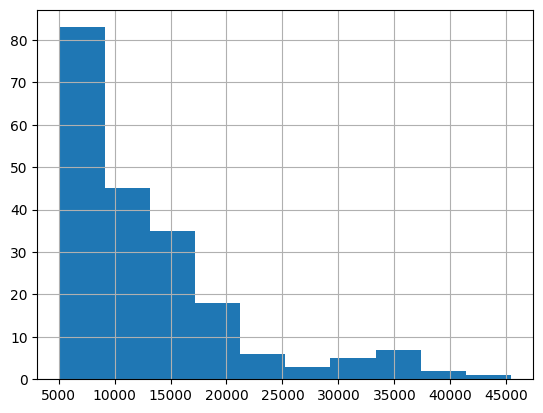

In [ ]:
df["price"].hist()

##

---

## Parte 2: Trasformazione e Predizione

### Domanda 01

Caricare il dataset, eliminare eventuali attributi inutili (giustificare la scelta), eliminare eventuali istanze duplicate, eliminare le istanze che contengono valori nulli, trasformare opportunamente i valori categorici (consiglio: usare Label Encoder) e dividere il dataset in train (3/4 del dataset) e test (1/4). Calcolare e valutare le predizioni di un RandomForestRegressor. Effettuare alcune considerazioni sui risultati ottenuti, calcolando la metrica RMSE.

In [ ]:
df.drop("car_ID", axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

> È stato rimosso l'attributo `car_ID` in quanto è un attributo superfluo per la predizione, oltre che creare potenzialmente dei problemi alla predizione creando regole inesistenti.

In [ ]:
from pandas.core.arrays import categorical
encoder = LabelEncoder()
categorical_columns = df.select_dtypes(include="object").columns
df[categorical_columns] = df[categorical_columns].apply(encoder.fit_transform)

In [ ]:
X, y = df.drop("price", axis=1), df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123)

In [ ]:
random_forest = RandomForestRegressor(random_state=123)
random_forest.fit(X_train, y_train)
y_pred_train = random_forest.predict(X_train)
y_pred_test = random_forest.predict(X_test)
print("RMSE train:", root_mean_squared_error(y_train, y_pred_train))
print("RMSE test:", root_mean_squared_error(y_test, y_pred_test))

RMSE train: 856.8931173357776
RMSE test: 1178.3571163798872


> La metrica RMSE è una metrica quantitativa, ci restituisce solamente un numero relativo a quanto il modello sbaglia, più è alto, più il modello sta commettendo degli errori. In questo caso, possiamo notare come la metrica sul test set sia altina, ma non possiamo dire tanto di più.

---

### Domanda 02

Creare una pipeline in cui, a partire dal dataset utilizzato al punto precedente, i valori degli attributi `carlength`, `carwidth` e `carheight` sono discretizzati in 5 intervalli, `citympg` e `highwaympg` sono trasformati con uno StandardScaler e tutti gli altri attributi sono lasciati invariati.

In [ ]:
discretizer = KBinsDiscretizer(n_bins=5)
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["carlength", "carwidth", "carheight"]),
        ("scaler", scaler, ["citympg", "highwaympg"]),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('discretizer', KBinsDiscretizer(),
                                 ['carlength', 'carwidth', 'carheight']),
                                ('scaler', StandardScaler(),
                                 ['citympg', 'highwaympg'])])

In [ ]:
pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("random_forest", random_forest),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(),
                                                  ['carlength', 'carwidth',
                                                   'carheight']),
                                                 ('scaler', StandardScaler(),
                                                  ['citympg', 'highwaympg'])])),
                ('random_forest', RandomForestRegressor(random_state=123))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)
print("RMSE train:", root_mean_squared_error(y_train, y_pred_train))
print("RMSE test:", root_mean_squared_error(y_test, y_pred_test))

RMSE train: 874.5128520139339
RMSE test: 1169.6157968905968


---

### Domanda 03

Creare una nuova pipeline che applica la SelectKBest al dataset utilizzato al punto 1 e aggiunge le componenti ottenute alle componenti della pipeline del punto precedente. Valutare i valori migliori di `k` di SelectKBest, del numero di intervalli in cui discretizzare `carlength`, `carwidth` e `carheight` e dei parametri `criterion` e `max_depth` del RandomForestRegressor. Ignorare eventuali warning. Confrontare i risultati con quelli ottenuti precedentemente.

In [ ]:
k_best = SelectKBest()

feature_union = FeatureUnion(
    transformer_list=[
        ("k_best", k_best),
        ("column_transformer", column_transformer),
    ],
)
feature_union

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


FeatureUnion(transformer_list=[('k_best', SelectKBest()),
                               ('column_transformer',
                                ColumnTransformer(remainder='passthrough',
                                                  transformers=[('discretizer',
                                                                 KBinsDiscretizer(),
                                                                 ['carlength',
                                                                  'carwidth',
                                                                  'carheight']),
                                                                ('scaler',
                                                                 StandardScaler(),
                                                                 ['citympg',
                                                                  'highwaympg'])]))])

In [ ]:
pipeline = Pipeline(
    steps=[
        ("feature_union", feature_union),
        ("random_forest", random_forest),
    ],
)
pipeline

Pipeline(steps=[('feature_union',
                 FeatureUnion(transformer_list=[('k_best', SelectKBest()),
                                                ('column_transformer',
                                                 ColumnTransformer(remainder='passthrough',
                                                                   transformers=[('discretizer',
                                                                                  KBinsDiscretizer(),
                                                                                  ['carlength',
                                                                                   'carwidth',
                                                                                   'carheight']),
                                                                                 ('scaler',
                                                                                  StandardScaler(),
                                                                                  ['citympg',
                                                                                   'highwaympg'])]))])),
                ('random_forest', RandomForestRegressor(random_state=123))])

In [ ]:
params = {
    "feature_union__k_best__k": [2, 4, 6],
    "feature_union__column_transformer__discretizer__n_bins": [5, 10, 15],
    "random_forest__criterion": ["squared_error", "absolute_error", "friedman_mse", "poisson"],
    "random_forest__max_depth": [None, 5, 10, 15, 20],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("RMSE test:", root_mean_squared_error(y_test, y_pred))
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/usr/local

RMSE test: 1150.4857656236898
Best params: {'feature_union__column_transformer__discretizer__n_bins': 15, 'feature_union__k_best__k': 2, 'random_forest__criterion': 'friedman_mse', 'random_forest__max_depth': None}
Best score: 0.9091271281914771


> Il risultato ottenuto grazie a `GridSearchCV` è un miglioramento delle performance della pipeline. La metrica RMSE cala rispetto al punto precedente di quasi 20.

---

### Domanda 04

Creare una pipeline che, a partire dal dataset originale, trasforma le colonne testuali in valori numerici e le feature numeriche attraverso lo StandardScaler e applica il RandomForestRegressor. Come variano le performance?

In [ ]:
df = pd.read_csv("dataset.csv")
df.drop("car_ID", axis=1, inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

In [ ]:
X, y = df.drop("price", axis=1), df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, random_state=123)

In [ ]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns
print(categorical_columns)
print(numerical_columns)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')
Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')


In [ ]:
one_hot = OneHotEncoder(handle_unknown="ignore")

column_transformer = ColumnTransformer(
    transformers=[
        ("one_hot", one_hot, categorical_columns),
        ("scaler", scaler, numerical_columns),
    ],
    remainder="passthrough",
)
column_transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('one_hot',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')),
                                ('scaler', StandardScaler(),
                                 Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object'))])

In [ ]:
best_criterion = grid_search.best_params_["random_forest__criterion"]
best_max_depth = grid_search.best_params_["random_forest__max_depth"]
random_forest = RandomForestRegressor(criterion=best_criterion, max_depth=best_max_depth, random_state=123)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("random_forest", random_forest),
    ],
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('one_hot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')),
                                                 ('scaler', StandardScaler(),
                                                  Index(['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight',
       'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
      dtype='object'))])),
                ('random_forest',
                 RandomForestRegressor(criterion='friedman_mse',
                                       random_state=123))])

In [ ]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("RMSE test:", root_mean_squared_error(y_test, y_pred))

RMSE test: 1159.1197207348682


> Le performance della pipeline risultano migliori di tutti i precedenti punti, ad esclusione del precedente, nel quale è stata usata anche una fase di selezione delle migliori `k` colonne. Rispetto al precedente punto, questa pipeline ha un RMSE maggiore di quasi 10.